## Employee Attrition as a Systems Signal: An Exploratory Modeling Study

This project explores employee attrition from a business analytics perspective, focusing on how workload, satisfaction, and career stage relate to the likelihood of employees leaving.

## Loading the dataset

I began by loading the HR attrition dataset and inspecting its structure. Before doing any modeling, I wanted to understand what variables were available and what kind of information they captured.

In [7]:
import os

file_path = r"C:\Users\priyanka\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv"

print(os.path.exists(file_path))

False


In [9]:
import pandas as pd

file_path = r"C:\Users\priyanka\Downloads\Archive\WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Initial exploration

Before jumping into patterns, I wanted to understand the size of the dataset, the available features, and the basic distribution of attrition.

df.shape

In [10]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [4]:
df['Attrition'].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [5]:
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
attrition_rate


Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## Department-level patterns

At a high level, I wanted to see whether attrition concentrates differently across departments.

In [6]:
df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()


Attrition,No,Yes
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


## Overtime and attrition

One of the first questions I wanted to explore was whether workload pressure might be linked to employees leaving. Overtime is a simple but powerful signal of workload intensity.

In [7]:
df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


In [8]:
df.groupby(['OverTime','PerformanceRating'])['Attrition'].value_counts(normalize=True).unstack()

Attrition                         No       Yes
OverTime PerformanceRating                    
No       3                  0.892497  0.107503
         4                  0.913043  0.086957
Yes      3                  0.703704  0.296296
         4                  0.646154  0.353846

## Career stage effects

I was also interested in whether attrition clusters around certain points in an employee’s timeline. Early career instability, mid-career stagnation 
can all show up differently in workforce data.

In [9]:
df.groupby('YearsAtCompany')['Attrition'].value_counts(normalize=True).unstack().head(15)

Attrition,No,Yes
YearsAtCompany,,
0,0.636364,0.363636
1,0.654971,0.345029
2,0.787402,0.212598
3,0.843750,0.156250
4,0.827273,0.172727
5,0.892857,0.107143
6,0.881579,0.118421
7,0.877778,0.122222
8,0.887500,0.112500


In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Performance and exit risk

One assumption I wanted to test was whether higher performance protects employees from leaving. In theory, strong performers should be more engaged and more likely to stay. But I was curious whether that assumption actually holds when viewed at scale.

In [11]:
df.groupby('PerformanceRating')['Attrition'].value_counts(normalize=True).unstack()

Attrition,No,Yes
PerformanceRating,,
3,0.839228,0.160772
4,0.836283,0.163717


In [12]:
df.groupby(['PerformanceRating','OverTime'])['Attrition'].value_counts(normalize=True).unstack()

Attrition                         No       Yes
PerformanceRating OverTime                    
3                 No        0.892497  0.107503
                  Yes       0.703704  0.296296
4                 No        0.913043  0.086957
                  Yes       0.646154  0.353846

In [13]:
df.groupby('YearsAtCompany')['Attrition'].value_counts(normalize=True).unstack()

Attrition,No,Yes
YearsAtCompany,,
0,0.636364,0.363636
1,0.654971,0.345029
2,0.787402,0.212598
3,0.843750,0.156250
4,0.827273,0.172727
5,0.892857,0.107143
6,0.881579,0.118421
7,0.877778,0.122222
8,0.887500,0.112500


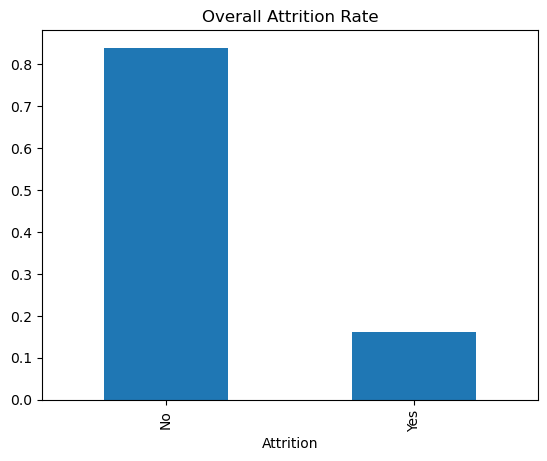

In [14]:
import matplotlib.pyplot as plt

df['Attrition'].value_counts(normalize=True).plot(kind='bar')
plt.title('Overall Attrition Rate')
plt.show()

## Overtime and attrition risk

This visualization looks at how overtime exposure relates to the probability of employees leaving. I was particularly interested in whether workload intensity shows up as a strong structural signal.

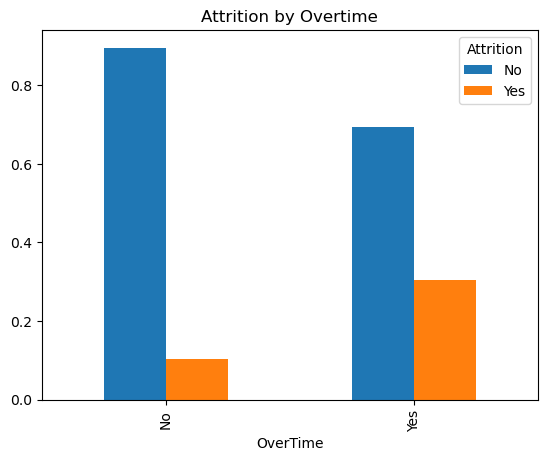

In [15]:
df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack().plot(kind='bar')
plt.title('Attrition by Overtime')
plt.show()

What stands out here is how sharply attrition probability increases among employees who work overtime. This suggests that workload pressure may be one of the most visible early indicators of potential exits.

In [16]:
df['Attrition_binary'] = df['Attrition'].map({'Yes':1, 'No':0})
df['Attrition_binary'].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition_binary, dtype: int64

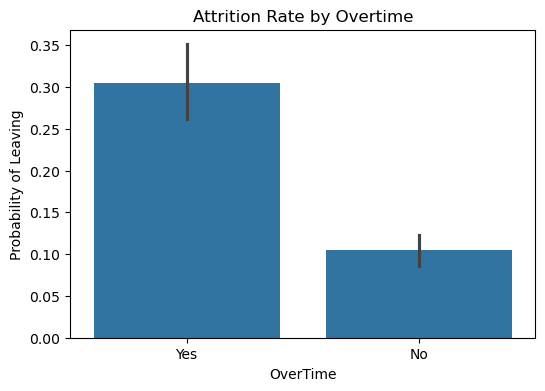

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    x='OverTime',
    y='Attrition_binary',
    data=df
)

plt.title('Attrition Rate by Overtime')
plt.ylabel('Probability of Leaving')
plt.xlabel('OverTime')
plt.show()

## Performance under workload pressure

This view combines performance rating with overtime exposure. I wanted to see whether strong performers handle overtime differently, or whether the added workload still increases exit risk.

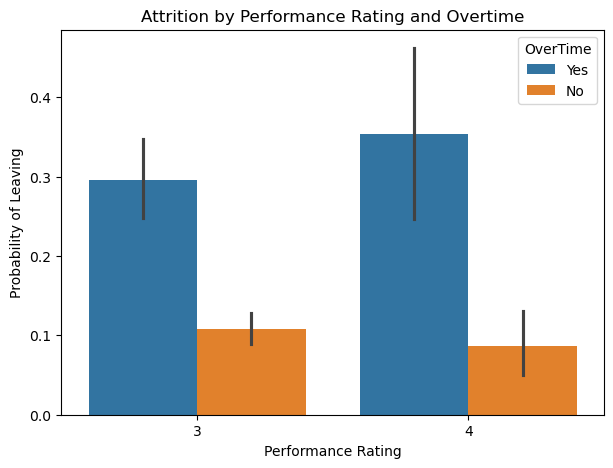

In [18]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='PerformanceRating',
    y='Attrition_binary',
    hue='OverTime',
    data=df
)

plt.title('Attrition by Performance Rating and Overtime')
plt.ylabel('Probability of Leaving')
plt.xlabel('Performance Rating')
plt.show()

Even among higher performers, overtime still appears to be associated with higher attrition probability. This suggests that performance alone may not offset workload strain.

## Attrition across career stages

This plot groups employees by tenure to see whether exit risk is concentrated at specific points in an employee’s time at a company.

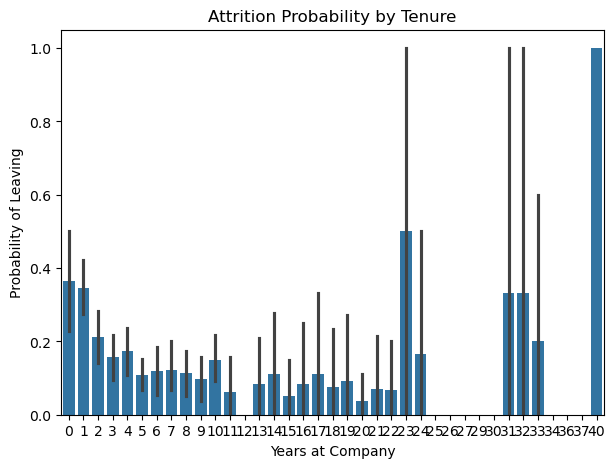

In [19]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='YearsAtCompany',
    y='Attrition_binary',
    data=df
)

plt.title('Attrition Probability by Tenure')
plt.ylabel('Probability of Leaving')
plt.xlabel('Years at Company')

plt.show()

Attrition appears to be highest early in an employee’s tenure and stabilizes over time. This pattern aligns with early adjustment challenges during initial years.

In [20]:
bins = [0,2,5,10,20,40]
labels = ['0-2','3-5','6-10','11-20','20+']

df['TenureGroup'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels, right=True)

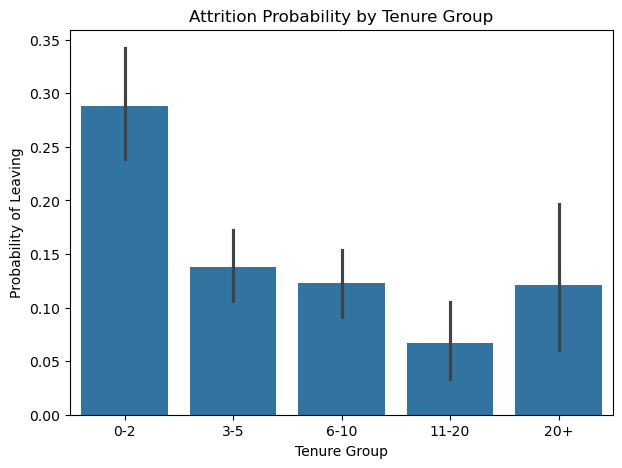

In [21]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='TenureGroup',
    y='Attrition_binary',
    data=df
)

plt.title('Attrition Probability by Tenure Group')
plt.ylabel('Probability of Leaving')
plt.xlabel('Tenure Group')

plt.show()

In [22]:
features = [
    'Age',
    'MonthlyIncome',
    'JobSatisfaction',
    'YearsAtCompany',
    'PerformanceRating'
]

X = df[features]
y = df['Attrition_binary']

## Modeling approach

After exploring patterns visually, I moved toward a simple predictive model to understand which factors consistently relate to attrition when considered together.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)

accuracy_score(y_test, preds)

0.8673469387755102

In [25]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
1,MonthlyIncome,-0.000072
0,Age,-0.026059
3,YearsAtCompany,-0.038689
4,PerformanceRating,-0.038805
2,JobSatisfaction,-0.256625


In [26]:
features = [
    'Age',
    'MonthlyIncome',
    'JobSatisfaction',
    'YearsAtCompany',
    'PerformanceRating',
    'OverTime',
    'WorkLifeBalance',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction'
]

In [27]:
df['OverTime_binary'] = df['OverTime'].map({'Yes':1, 'No':0})

In [28]:
features = [
    'Age',
    'MonthlyIncome',
    'JobSatisfaction',
    'YearsAtCompany',
    'PerformanceRating',
    'OverTime_binary',
    'WorkLifeBalance',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction'
]

In [29]:
X = df[features]
y = df['Attrition_binary']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [33]:
preds = model.predict(X_test)
accuracy_score(y_test, preds)

0.8639455782312925

In [34]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient')

coefficients

,Feature,Coefficient
2,JobSatisfaction,-0.332269
7,EnvironmentSatisfaction,-0.296447
6,WorkLifeBalance,-0.252390
4,PerformanceRating,-0.115129
8,RelationshipSatisfaction,-0.075970
3,YearsAtCompany,-0.033709
0,Age,-0.030794
1,MonthlyIncome,-0.000082
5,OverTime_binary,1.646416


## What the model is picking up

What stood out most to me was how strongly overtime appears in the model. Even after accounting for satisfaction, tenure, income, and performance, workload still shows a clear relationship with attrition. Satisfaction-related variables also consistently show up as protective signals suggesting that everyday experience inside the workplace may matter more than static characteristics like age or income.

In [35]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, preds)

array([[251,   4],
       [ 36,   3]])

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.87      0.98      0.93       255
           1       0.43      0.08      0.13        39

    accuracy                           0.86       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.82      0.86      0.82       294



## Structural Signal Construction
Rather than immediately moving into modeling, I want to first construct systemic indicators that may reflect organizational strain since attrition is rarely random and it often emerges from accumulated pressure signals embedded in daily work conditions.
My goal here is to:
- Convert attrition into a numeric signal
- Construct a Pressure_Index that captures operational strain
- Test whether pressure levels differ between those who stayed vs those who left

### Pressure Index Construction
Pressure inside a workplace does not come from one variable, it is often a combination of: 
- Overtime load
- Work-life imbalance
- Dissatisfaction with environment
- High involvement intensity

In [12]:
# Convert OverTime to numeric
df["OverTime_Flag"] = df["OverTime"].map({"Yes": 1, "No": 0})

In [13]:
# Construct composite pressure signal
df["Pressure_Index"] = (
    df["OverTime_Flag"] * 1.5 + 
    (5 - df["WorkLifeBalance"]) + 
    (5 - df["EnvironmentSatisfaction"]) + 
    df["JobInvolvement"]
) / 4

df["Pressure_Index"].describe()

count    1470.000000
mean        1.917857
std         0.406680
min         0.750000
25%         1.625000
50%         1.875000
75%         2.250000
max         3.125000
Name: Pressure_Index, dtype: float64

Higher values indicate greater strain while lower values indicate stability. I will now examine whether pressure differs between employees who left and those who stayed.

In [15]:
df["Attrition_Flag"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [16]:
df[["Attrition", "Attrition_Flag"]].head()

,Attrition,Attrition_Flag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [17]:
df.groupby("Attrition_Flag")["Pressure_Index"].mean()

Attrition_Flag
0    1.892437
1    2.050105
Name: Pressure_Index, dtype: float64

### Pressure Differences by Attrition
Employees who left show a higher average Pressure_Index than those who stayed. While the difference is not extreme, it suggests that accumulated strain may contribute to attrition risk.

## Overconfidence_Index Construction
Beyond pressure, I also examined structural overconfidence risk. This index captures the combination of:
- PerformanceRating
- PercentSalaryHike
- Low JobSatisfaction
- Low EnvironmentSatisfaction
The goal here is to identify potential high-impact instability nodes.

In [18]:
# Construct Overconfidence Index

df["Overconfidence_Index"] = (
    df["PerformanceRating"] +
    df["PercentSalaryHike"] / 10 +
    (5 - df["JobSatisfaction"]) +
    (5 - df["EnvironmentSatisfaction"])
) / 4

df["Overconfidence_Index"].describe()

count    1470.000000
mean        2.306088
std         0.425286
min         1.525000
25%         2.025000
50%         2.300000
75%         2.593750
max         3.625000
Name: Overconfidence_Index, dtype: float64

### Overconfidence Differences by Attrition
Employees who left show a higher average Overconfidence_Index compared to those who stayed.
Stayed: ~2.28  
Left: ~2.43  
This suggests that employees who appear structurally strong (high performance and compensation signals) may still carry dissatisfaction risk. Overconfidence risk appears slightly elevated among leavers.

In [19]:
df.groupby("Attrition_Flag")["Overconfidence_Index"].mean()

Attrition_Flag
0    2.281630
1    2.433333
Name: Overconfidence_Index, dtype: float64

## Attrition Probability Across Pressure Levels
Rather than only comparing averages, I examined how attrition probability changes as pressure increases.

In [21]:
# Create pressure quartiles
df["Pressure_Band"] = pd.qcut(df["Pressure_Index"], q=4, labels=["Low", "Moderate", "High", "Extreme"])

df.groupby("Pressure_Band")["Attrition_Flag"].mean()

C:\Users\priyanka\AppData\Local\Temp\ipykernel_8748\3406905609.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Pressure_Band")["Attrition_Flag"].mean()


Pressure_Band
Low         0.095607
Moderate    0.157895
High        0.170782
Extreme     0.254237
Name: Attrition_Flag, dtype: float64

### Attrition Probability by Pressure Band
Attrition rates rise steadily across pressure levels. This represents nearly a 3x increase in attrition risk between the lowest and highest pressure groups.

## Visualizing Pressure vs Attrition Risk
To make the structural pattern clearer, I visualized attrition probability across pressure bands.

C:\Users\priyanka\AppData\Local\Temp\ipykernel_8748\3217646474.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pressure_attrition = df.groupby("Pressure_Band")["Attrition_Flag"].mean()


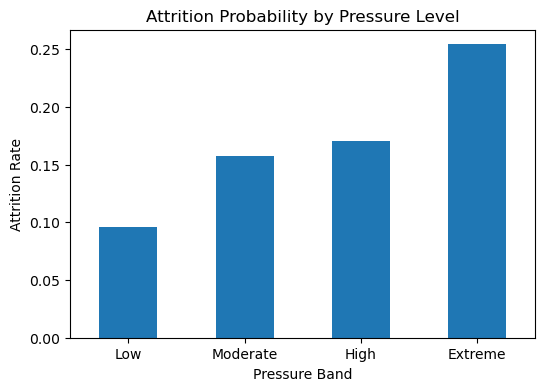

In [22]:
import matplotlib.pyplot as plt

pressure_attrition = df.groupby("Pressure_Band")["Attrition_Flag"].mean()

plt.figure(figsize=(6,4))
pressure_attrition.plot(kind="bar")
plt.title("Attrition Probability by Pressure Level")
plt.ylabel("Attrition Rate")
plt.xlabel("Pressure Band")
plt.xticks(rotation=0)
plt.show()

## Logistic Regression: Structural Validation
To further test whether Pressure_Index and Overconfidence_Index carry structural weight, I estimated a logistic regression model predicting attrition probability.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select structural predictors
X = df[["Pressure_Index", "Overconfidence_Index"]]
y = df["Attrition_Flag"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

model.coef_

array([[0.2898669 , 0.18959785]])

### Logistic Regression Coefficients
Both coefficients are positive. This would indicate that higher structural pressure and higher overconfidence risk are associated with increased attrition probability. Pressure_Index shows stronger weight, suggesting strain may be a more dominant structural signal than overconfidence instability.

In [24]:
# Create predicted probabilities
df["Predicted_Attrition_Prob"] = model.predict_proba(
    scaler.transform(df[["Pressure_Index", "Overconfidence_Index"]])
)[:, 1]

# Examine probability across pressure bands
df.groupby("Pressure_Band")["Predicted_Attrition_Prob"].mean()

C:\Users\priyanka\AppData\Local\Temp\ipykernel_8748\1669850121.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Pressure_Band")["Predicted_Attrition_Prob"].mean()


Pressure_Band
Low         0.110133
Moderate    0.143812
High        0.192438
Extreme     0.256796
Name: Predicted_Attrition_Prob, dtype: float64

### Model-Implied Attrition Probability Across Pressure Bands
The predicted probabilities increase consistently with pressure level and this also suggests that the constructed Pressure_Index captures meaningful instability dynamics rather than random noise.

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

[[380   0]
 [ 61   0]]


              precision    recall  f1-score   support

           0       0.86      1.00      0.93       380
           1       0.00      0.00      0.00        61

    accuracy                           0.86       441
   macro avg       0.43      0.50      0.46       441
weighted avg       0.74      0.86      0.80       441



C:\Users\priyanka\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priyanka\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priyanka\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Model Evaluation and Class Imbalance
The logistic regression model predicts the majority class (non-attrition) almost exclusively. While overall accuracy is ~86%, the model fails to correctly classify attrition cases due to class imbalance (attrition is relatively rare in the dataset). This suggests that attrition is not evenly distributed, and naive predictive models may under-detect high-risk employees unless imbalance is addressed.

## Limitations and Next Steps
- Class imbalance affecting predictive classification
- Cross-sectional rather than time-series data
Future extensions could include:
- Time-based attrition modeling
- Team-level aggregation effects
In conclusion, attrition risk appears to rise systematically with accumulated strain and masked dissatisfaction among high performers in an organization.